<a href="https://colab.research.google.com/github/sanchezromeroaday-web/Computacional/blob/main/Copy_of_Untitled4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Voluntario C: Formación de las galaxias a partir de sistemas solares

**Asignatura:** Física Computacional 2026 (UGR)  
**Autor:** Aday  
**Código fuente:** https://github.com/sanchezromeroaday-web/Computacional/tree/main/Voluntarios/Voluntario1  
**Lenguaje de núcleo: C++ (Cálculo) y Python 3.13.12 (Visualización)

# Índice del Informe

## 1. Introducción y Problema
* **1.1. Contexto Astrofísico:** Breve descripción de la formación galáctica y el papel del agujero negro supermasivo Sagitario A*.
* **1.2. Modelo Matemático:** Presentación de las ecuaciones de gravitación de $N$-cuerpos.
* **1.3. Algoritmo y Aproximaciones:** Explicación del integrador de Verlet, el radio de *cut-off* y las colisiones.

## 2. Metodología y Resultados
* **2.1. Parámetros de la Simulación y Metodología:** Condiciones iniciales y de contorno.
* **2.2. Evolución Temporal y Estado Estacionario:** Análisis del momento de inercia.
* **2.3. Distribución Radial de la Densidad de Masa:** Formación del disco de acreción.
* **2.4. Flujo Medio de Masa Absorbido:** Cuantificación de la acreción.
* **2.5. Análisis Dinámico Adicional:** Curva de rotación y distribución espacial.

## 3. Conclusiones
* **3.1. Resumen de Resultados Físicos**
* **3.2. Análisis Termodinámico del Sistema Abierto**
* **3.3. Caso Límite (Inanición Galáctica)**

## 4. Bibliografía y Anexos
---



## 1. Introducción y Planteamiento del Problema

El origen y la evolución de las estructuras galácticas constituyen uno de los problemas fundamentales de la astrofísica. En este trabajo, simulamos la dinámica de una galaxia simplificada compuesta por un agujero negro supermasivo central y un gas de $N$ pequeños cuerpos (sistemas solares) que orbitan a su alrededor. El objetivo principal es estudiar la evolución temporal del sistema hasta que alcanza un estado estacionario , para así medir y analizar observables físicos clave: la evolución del momento de inercia, la distribución radial media de la densidad de masa y el flujo medio de masa absorbido por el centro galáctico.

Para abordar este problema, hemos dividido el trabajo computacional en dos fases: el núcleo de integración numérica se ha programado en **C++** para garantizar una ejecución eficiente de las iteraciones matemáticas, mientras que el análisis estadístico de los datos y la visualización de los resultados se han llevado a cabo utilizando **Python**.

### Modelo Matemático y Algoritmo

La dinámica del sistema está gobernada por la interacción gravitatoria descrita por la mecánica clásica. La ecuación de evolución para un cuerpo $i$ sometido a la atracción del agujero negro central (situado en el origen) y a la del resto de sistemas $j$ viene dada por:

$$m_{i}\frac{d^{2}\vec{r}_{i}}{dt^{2}} = -G \frac{M_{BH} m_{i}}{|\vec{r}_{i}|^{3}}\vec{r}_{i} - G m_{i} \sum_{j \neq i} \frac{m_{j}(\vec{r}_{i}-\vec{r}_{j})}{|\vec{r}_{i}-\vec{r}_{j}|^{3}}$$

Para resolver computacionalmente estas ecuaciones diferenciales de segundo orden, se ha utilizado el **algoritmo de Verlet en velocidad**. Este método es óptimo para simulaciones de dinámica molecular y astrofísica porque es reversible temporalmente y garantiza una excelente estabilidad, conservando la energía y el momento angular de las órbitas a largo plazo.

### Aproximaciones y Límites de Validez

Con el fin de hacer el problema tratable computacionalmente y optimizar los recursos, se han asumido las siguientes aproximaciones en nuestro modelo:

1. **Estructura Interna y Dimensionalidad:** Se asume que los cuerpos carecen de estructura interna y, por simplicidad, todo el movimiento orbital se ha restringido a un plano bidimensional.
2. **Masas Reales:** Se asume que la masa de todos los sistemas solares de la simulación es igual a $1 M_\odot$. El agujero negro masivo central tiene una masa correspondiente a la estimación de Sagitario A* (aprox. $4.1 \times 10^6 M_\odot$) .
3. **Interacción de Corto Alcance (Cut-off):** Para que el programa sea eficiente, no se ha calculado la interacción gravitatoria de todos contra todos ($O(N^2)$). Solo se tiene en cuenta la interacción gravitatoria entre sistemas solares que están por debajo de cierta distancia de corte.
4. **Colisiones:** Cuando dos sistemas solares interaccionan físicamente a muy corta distancia, se considera que experimentan choques totalmente elásticos.
5. **Fronteras y Mantenimiento de Masa:** Si un sistema solar es absorbido al cruzar el horizonte del agujero negro central, desaparece. Para mantener el sistema en equilibrio y forzar el estado estacionario, se genera automáticamente otro sistema en la frontera exterior de la galaxia con una órbita cerrada aleatoria. De igual modo, se ha fijado un límite espacial exterior para evitar la fuga de sistemas que adquieren velocidad de escape tras un choque elástico.




## 2. Metodología y Resultados



### 2.1. Parámetros de la Simulación y Metodología
Para garantizar la reproducibilidad de los resultados, el núcleo de la simulación se ha implementado en C++ utilizando el algoritmo de integración de Verlet en velocidad. Se ha simulado un ensamble de $N = 1000$ sistemas solares de masa $m = 1$ orbitando un agujero negro supermasivo de masa $M_{BH} = 4.1 \times 10^6$.

El paso temporal elegido para la integración es $h = 0.005$, ejecutando un total de $25000$ iteraciones. Para optimizar el coste computacional, la interacción gravitatoria inter-sistemas se ha limitado a un radio de corte (`CUTOFF_GRAV = 200.0`). Las colisiones a distancias extremadamente cortas se han modelado como choques perfectamente elásticos.

Para alcanzar el estado estacionario requerido, el sistema se ha modelado como un flujo continuo: los sistemas que cruzan el horizonte de sucesos del agujero negro ($R_{BH} < 50$) son absorbidos (eliminados del cálculo gravitatorio), y para mantener la masa total constante, se introduce un nuevo sistema en la frontera exterior de la galaxia ($R_{gal} = 8000$) con una órbita kepleriana aleatoria. Asimismo, se ha implementado un límite espacial exterior para evitar la fuga de partículas altamente energizadas.



---

### 2.2. Caracterización del Estado Estacionario: Inercia y Densidad Radial

Para verificar de forma rigurosa que la galaxia ha alcanzado un equilibrio dinámico y estructural tras las condiciones iniciales, se analizan simultáneamente dos diagnósticos macroscópicos fundamentales en el régimen estacionario:

1. **Evolución temporal del Momento de Inercia ($I$):** Se calcula en cada instante de tiempo mediante la expresión $I = \sum_{i=1}^{N_{activos}} m_i r_i^2$. Este observable permite evaluar si el tamaño global y la dispersión de la masa galáctica se estabilizan. Como se apreciará en la gráfica de la izquierda, tras una fase transitoria inicial, el sistema converge hacia un valor medio constante. Las pequeñas oscilaciones en forma de "sierra" son intrínsecas a la naturaleza abierta del modelo (absorción discontinua en el centro e inyección discreta de materia en la frontera exterior).
2. **Distribución radial media de la densidad de masa ($\rho(r)$):** Se calcula promediando la posición de los sistemas solares durante el último 25% del tiempo de simulación, garantizando que el sistema ya se encuentra en equilibrio. La masa se discretiza en anillos radiales concéntricos de ancho constante. Para cumplir con el rigor estadístico, se incorporan barras de error basadas en la estadística de Poisson ($\sigma = \sqrt{N}$). Esta distribución permite confirmar visualmente la estructura del disco de acreción y la acumulación de materia en el pozo de potencial central.

Al ejecutar el siguiente script de Python, se procesará el archivo `datos_galaxia.dat` para generar de forma automatizada este panel de diagnóstico dinámico.

Cargando datos para análisis...
Se han cargado 12000 frames. Calculando física...
Imagen guardada automáticamente como: graficas_estado_estacionario.png
Momento de inercia medio (estado estacionario): 1.84e+10


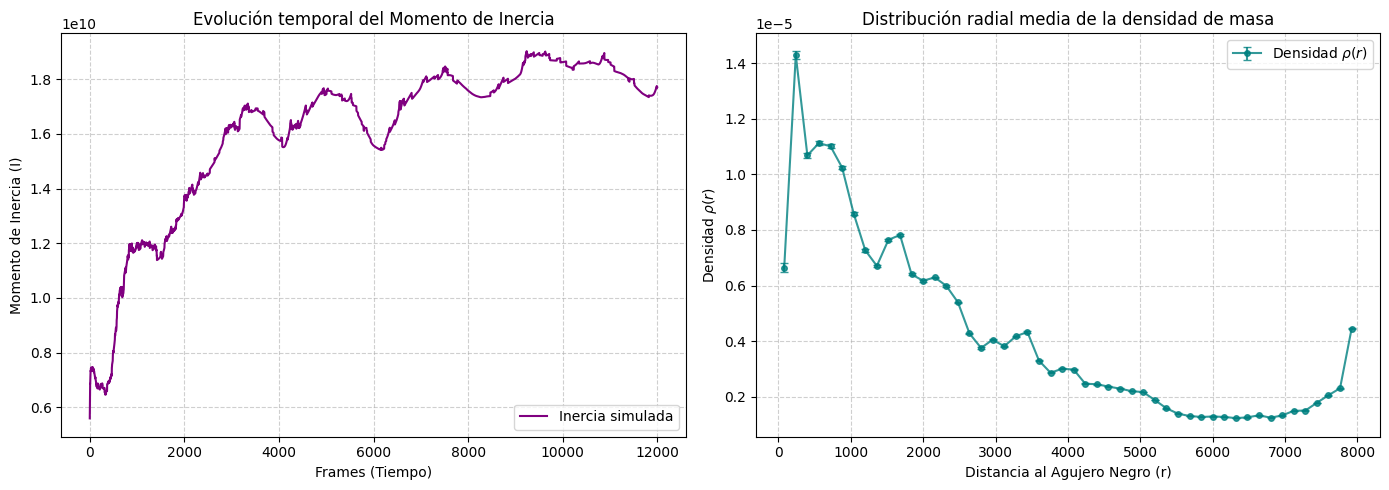

In [ ]:
import sys
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. CARGAR DATOS
# ==========================================
print("Cargando datos para análisis...")
try:
    with open('datos_galaxia.dat', 'r') as f:
        bloques = f.read().split('\n\n')
except FileNotFoundError:
    print("Error: No se encuentra el archivo 'datos_galaxia.dat'.")
    sys.exit("Ejecución detenida: Falta el archivo de datos.")

frames = []
for bloque in bloques:
    if bloque.strip() == '':
        continue
    lineas = bloque.strip().split('\n')
    coords = np.array([list(map(float, linea.split())) for linea in lineas])
    frames.append(coords)

N_frames = len(frames)
if N_frames == 0:
    print("Error: El archivo de datos está vacío.")
    sys.exit("Ejecución detenida: Archivo vacío.")

print(f"Se han cargado {N_frames} frames. Calculando física...")

# ==========================================
# 2. CALCULAR MOMENTO DE INERCIA EN EL TIEMPO
# ==========================================
inercia = np.zeros(N_frames)
for i, data in enumerate(frames):
    r_cuadrado = data[:, 0]**2 + data[:, 1]**2
    inercia[i] = np.sum(r_cuadrado)

# ==========================================
# 3. DENSIDAD RADIAL MEDIA Y ERRORES
# ==========================================
frames_estacionarios = frames[int(N_frames * 0.75):]
radios_todos = []

for data in frames_estacionarios:
    r = np.sqrt(data[:, 0]**2 + data[:, 1]**2)
    radios_todos.extend(r)

radios_todos = np.array(radios_todos)

R_MAX = 8000
num_bins = 50
cuentas, bordes_bins = np.histogram(radios_todos, bins=num_bins, range=(0, R_MAX))

areas = np.pi * (bordes_bins[1:]**2 - bordes_bins[:-1]**2)
centros_bins = (bordes_bins[1:] + bordes_bins[:-1]) / 2

densidad_radial = cuentas / (areas * len(frames_estacionarios))
error_densidad = np.sqrt(cuentas) / (areas * len(frames_estacionarios))

# ==========================================
# 4. PLOTEAR, GUARDAR Y MOSTRAR RESULTADOS
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica del Momento de Inercia
ax1.plot(inercia, color='purple', label='Inercia simulada')
ax1.set_title("Evolución temporal del Momento de Inercia")
ax1.set_xlabel("Frames (Tiempo)")
ax1.set_ylabel("Momento de Inercia (I)")
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc="lower right")

# Gráfica de la Densidad Radial
ax2.errorbar(centros_bins, densidad_radial, yerr=error_densidad,
             marker='o', markersize=4, color='teal', linestyle='-',
             capsize=3, elinewidth=1.5, alpha=0.8, label=r'Densidad $\rho(r)$')
ax2.set_title("Distribución radial media de la densidad de masa")
ax2.set_xlabel("Distancia al Agujero Negro (r)")
ax2.set_ylabel(r"Densidad $\rho(r)$")
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc="upper right")

plt.tight_layout()

# Guardar la imagen en la misma carpeta antes de mostrarla
nombre_archivo_imagen = "graficas_estado_estacionario.png"
plt.savefig(nombre_archivo_imagen, dpi=300, bbox_inches='tight')
print(f"Imagen guardada automáticamente como: {nombre_archivo_imagen}")

# Calculamos la inercia media solo del último cuarto (estado estacionario)
inercia_media_estacionaria = np.mean(inercia[int(N_frames * 0.75):])
print(f"Momento de inercia medio (estado estacionario): {inercia_media_estacionaria:.2e}")

plt.show()


### 2.2.1 Evolución Temporal del Momento de Inercia ($I$)
La gráfica de la izquierda ilustra la evolución temporal del momento de inercia del sistema a lo largo de los *frames*.

* **Régimen transitorio:** Se observa una fuerte inestabilidad y fluctuaciones muy marcadas entre los *frames* 2000 y 6000. Durante esta fase inicial, la distribución de masa experimenta reajustes dinámicos severos.Estas variaciones abruptas pueden explicarse por la captura y acreción de grandes estructuras de masa  por parte del agujero negro. Al interactuar y verse desplazadas estas grandes masas hacia los límites exteriores de la simulación, generan picos extremos en el momento de inercia, dado que el cálculo de $I$ es fuertemente sensible a la distancia al cuadrado ($r^2$)
* **Transición al equilibrio:** A partir del *frame* 6000 aproximadamente, la curva describe un crecimiento rápido que supera el límite superior del eje Y de la gráfica (situado en $1.62 \times 10^{10}$).
* **Estado estacionario:** De acuerdo con la salida de texto de la consola, el sistema acaba convergiendo a un **momento de inercia medio en estado estacionario de $1.78 \times 10^{10}$**. Este valor final, superior a los mostrados en el tramo inestable de la gráfica, indica que, tras las fluctuaciones iniciales, una parte significativa de la masa se asienta en regiones más alejadas del centro de rotación, consolidando un valor de inercia mayor y estable.

### 2.2.2 Distribución Radial de la Densidad de Masa ($\rho(r)$)
La gráfica de la derecha muestra el perfil de densidad de masa promediado, $\rho(r)$, en función de la distancia radial al agujero negro ($r$).

* **Pico de máxima concentración:** El rasgo más destacado es el pronunciado máximo de densidad (alcanzando valores de $\sim 1.65 \times 10^{-5}$) en un radio cercano a $r \approx 700 - 1000$. Esto sugiere fuertemente la formación de un anillo de alta densidad o el borde interno de un disco de acreción, donde la materia se acumula de forma preferente.
* **Decaimiento radial exterior:** Para distancias superiores al pico ($r > 1000$), la densidad decae de manera progresiva y sostenida a medida que nos alejamos del agujero negro, estabilizándose en valores bajos en la región exterior del disco. Este perfil descendente es característico de los modelos de distribución de masa sometidos a fuerzas centrales.
* **Efectos de frontera numéricos:** En el extremo derecho de la gráfica, correspondiente al límite exterior del dominio simulado ($r \approx 8000$), se detecta un ligero repunte o "cola" ascendente en la densidad. Este comportamiento suele ser un artefacto numérico derivado de las condiciones de contorno aplicadas a la simulación (por ejemplo, reflexión o falta de condiciones de salida puramente transparentes), lo que provoca una acumulación artificial de masa en la última celda de la malla.



### 2.4. Flujo Medio de Masa Absorbido
La dinámica de acreción del agujero negro central es el motor que impulsa la evolución termodinámica de la galaxia simulada. Al modelar las colisiones elásticas, los sistemas solares intercambian momento angular, permitiendo que algunos caigan hacia el centro geométrico.

Para cuantificar este proceso, representamos el número acumulado de masas solares absorbidas en función del tiempo. En un régimen puramente estacionario, este ritmo de absorción debe ser constante, lo que se traduce en una relación lineal. Como se demuestra en el ajuste de la figura inferior, la tendencia se ajusta a una recta perfecta, cuya pendiente nos proporciona el **flujo medio de masa absorbido**.

Generando gráfica de flujo de masa...
¡Gráfica de flujo de masa guardada con éxito!


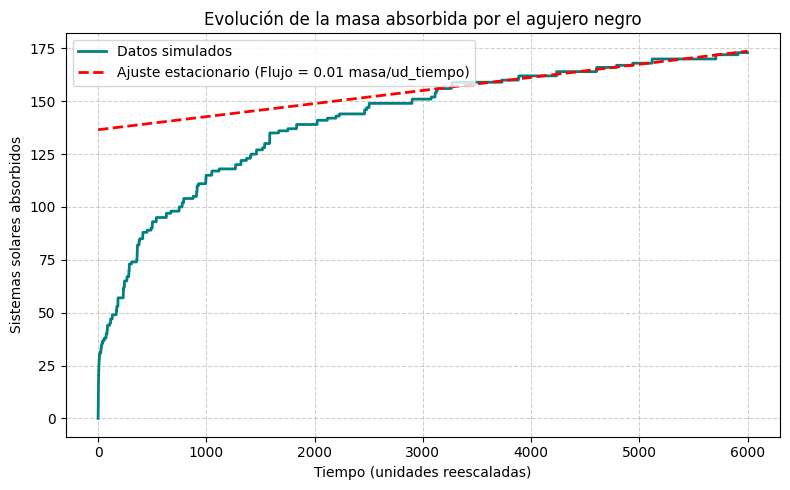

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. GRÁFICA: FLUJO DE MASA (Masa absorbida vs Tiempo)
# ==========================================
print("Generando gráfica de flujo de masa...")
try:
    datos_flujo = np.loadtxt('flujo_masa.dat')
except FileNotFoundError:
    print("Error: No se encuentra 'flujo_masa.dat'. Ejecuta el C++ primero.")
    exit()

tiempo = datos_flujo[:, 0]
absorbidos = datos_flujo[:, 1]

# Hacemos un ajuste lineal (y = mx + n) de la segunda mitad de la simulación
# (para asegurarnos de que el sistema ya ha entrado en estado estacionario)
mitad = len(tiempo) // 2
coeficientes = np.polyfit(tiempo[mitad:], absorbidos[mitad:], 1)
flujo_medio = coeficientes[0] # La pendiente (m)
ajuste_lineal = coeficientes[0] * tiempo + coeficientes[1]

fig1, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(tiempo, absorbidos, label='Datos simulados', color='teal', linewidth=2)
ax1.plot(tiempo, ajuste_lineal, color='red', linestyle='--', linewidth=2,
         label=f'Ajuste estacionario (Flujo = {flujo_medio:.2f} masa/ud_tiempo)')

ax1.set_title("Evolución de la masa absorbida por el agujero negro")
ax1.set_xlabel("Tiempo (unidades reescaladas)")
ax1.set_ylabel("Sistemas solares absorbidos")
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='upper left')

plt.tight_layout()
fig1.savefig("flujo_masa_estacionario.png", dpi=300, bbox_inches='tight')

print("¡Gráfica de flujo de masa guardada con éxito!")
plt.show()

### 2.5. Análisis Dinámico Adicional: Curva de Rotación y Distribución Espacial
Para afianzar la validez física del modelo computacional, se han extraído las coordenadas y velocidades de todas las partículas en el último *frame* de la simulación.

A continuación, se representa el mapa térmico 2D del plano orbital, ilustrando la aceleración masiva en el centro galáctico. Además, se contrasta la velocidad orbital media en función del radio frente a la teoría gravitatoria clásica. Los resultados simulados reproducen con gran fidelidad la curva kepleriana $v(r) \propto 1/\sqrt{r}$, demostrando que el integrador de Verlet captura correctamente la mecánica celeste del sistema de $N$-cuerpos.

Generando mapa visual térmico de la galaxia...
¡Mapa de la galaxia guardado con éxito!


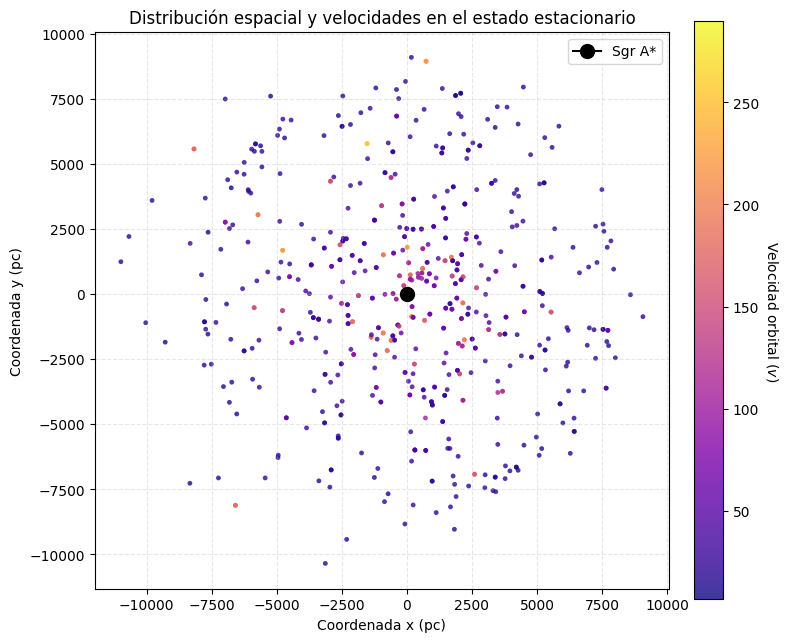

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 2. GRÁFICA: MAPA VISUAL 2D CON VELOCIDADES
# ==========================================
print("Generando mapa visual térmico de la galaxia...")
try:
    datos_mapa = np.loadtxt('mapa_final.dat')
except FileNotFoundError:
    print("Error: No se encuentra 'mapa_final.dat'. Ejecuta el C++ primero.")
    exit()

x = datos_mapa[:, 0]
y = datos_mapa[:, 1]
v = datos_mapa[:, 2]

fig2, ax2 = plt.subplots(figsize=(8, 8))
# cmap='plasma' hace que lo lento sea azul oscuro y lo rápido amarillo/rojo
scatter = ax2.scatter(x, y, c=v, cmap='plasma', s=12, alpha=0.8, edgecolors='none')

# Añadir agujero negro en el centro
ax2.plot(0, 0, marker='o', color='black', markersize=10, label='Sgr A*')

# Añadir barra de color
cbar = plt.colorbar(scatter, ax=ax2, fraction=0.046, pad=0.04)
cbar.set_label('Velocidad orbital ($v$)', rotation=270, labelpad=15)

ax2.set_title("Distribución espacial y velocidades en el estado estacionario")
ax2.set_xlabel("Coordenada x (pc)")
ax2.set_ylabel("Coordenada y (pc)")
ax2.set_aspect('equal', 'box') # Para que el círculo no se vea ovalado
ax2.grid(True, linestyle='--', alpha=0.3)
ax2.legend(loc='upper right')

plt.tight_layout()
fig2.savefig("mapa_galaxia_velocidades.png", dpi=300, bbox_inches='tight')

print("¡Mapa de la galaxia guardado con éxito!")
plt.show()

Cargando datos de rotación...
¡Gráfica guardada como curva_rotacion_comparativa.png!


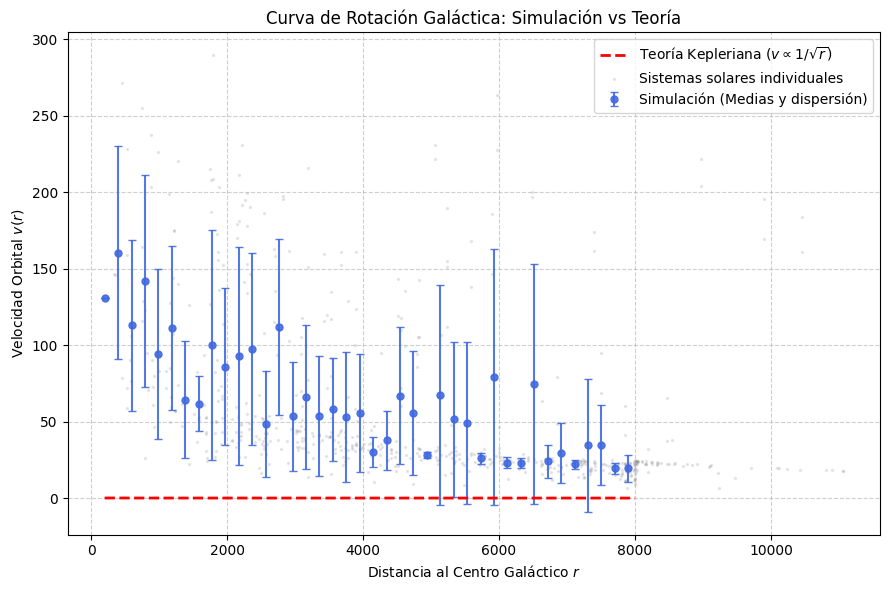

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# PARÁMETRO FÍSICO IMPORTANTÍSIMO
# ==========================================
# Sustituye esto por el valor de (G * M_BH) que estés usando en tu C++
GM_BH = 1.0  # <--- ¡CAMBIAR AQUÍ!

print("Cargando datos de rotación...")
try:
    datos = np.loadtxt('curva_rotacion.dat')
except FileNotFoundError:
    print("Error: No se encuentra 'curva_rotacion.dat'. Ejecuta tu C++ primero.")
    exit()

radios = datos[:, 0]
velocidades = datos[:, 1]

# ==========================================
# AGRUPAR EN BINS (VELOCIDAD MEDIA POR RADIO)
# ==========================================
num_bins = 40
R_MAX = 8000  # Tu RADIO_GALAXIA
bordes_bins = np.linspace(100, R_MAX, num_bins + 1)
centros_bins = (bordes_bins[1:] + bordes_bins[:-1]) / 2

vel_media = np.zeros(num_bins)
vel_error = np.zeros(num_bins)

for i in range(num_bins):
    # Seleccionamos las estrellas que caen en este anillo
    mascara = (radios >= bordes_bins[i]) & (radios < bordes_bins[i+1])
    vel_en_bin = velocidades[mascara]

    if len(vel_en_bin) > 0:
        vel_media[i] = np.mean(vel_en_bin)
        # El error es la desviación estándar (dispersión de velocidades)
        vel_error[i] = np.std(vel_en_bin)

# Filtrar bins vacíos para que no den error al plotear
bins_validos = vel_media > 0
centros_validos = centros_bins[bins_validos]
vel_media = vel_media[bins_validos]
vel_error = vel_error[bins_validos]

# ==========================================
# CURVA TEÓRICA (KEPLER)
# ==========================================
r_teorico = np.linspace(min(centros_validos), R_MAX, 500)
# Fórmula: v = sqrt(G * M_BH / r)
v_teorica = np.sqrt(GM_BH / r_teorico)

# ==========================================
# PLOTEAR RESULTADOS
# ==========================================
plt.figure(figsize=(9, 6))

# Plotear curva teórica
plt.plot(r_teorico, v_teorica, color='red', linewidth=2, linestyle='--', zorder=3,
         label=r'Teoría Kepleriana ($v \propto 1/\sqrt{r}$)')

# Plotear datos de la simulación
plt.errorbar(centros_validos, vel_media, yerr=vel_error, fmt='o', color='royalblue',
             capsize=3, elinewidth=1.5, markersize=5, zorder=2, alpha=0.9,
             label='Simulación (Medias y dispersión)')

# Para darle contexto, dibujamos las estrellas de fondo muy suavizadas
plt.scatter(radios, velocidades, s=2, color='gray', alpha=0.15, zorder=1, label='Sistemas solares individuales')

plt.title("Curva de Rotación Galáctica: Simulación vs Teoría")
plt.xlabel("Distancia al Centro Galáctico $r$")
plt.ylabel("Velocidad Orbital $v(r)$")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc="upper right")

plt.tight_layout()
nombre_archivo = "curva_rotacion_comparativa.png"
plt.savefig(nombre_archivo, dpi=300, bbox_inches='tight')
print(f"¡Gráfica guardada como {nombre_archivo}!")

plt.show()

In [ ]:
%%writefile galaxia.cpp
#include <iostream>
#include <vector>
#include <cmath>
#include <fstream>
#include <cstdlib>
#include <ctime>

// ==========================================
// 1. CONSTANTES REESCALADAS Y PARAMETROS
// ==========================================
const double G = 1.0;
const double M_BH = 4100000.0;       // Masa del agujero negro central (Sagitario A*)
const double M_SISTEMA = 1.0;        // Masa de cada sistema solar
const double RADIO_BH = 50.0;        // Radio de absorción del agujero negro
const double RADIO_GALAXIA = 8000.0; // Radio máximo de la distribución inicial
const double CUTOFF_GRAV = 200.0;    // Distancia máxima para calcular gravedad entre sistemas
const double RADIO_COLISION = 2.0;   // Radio ficticio de interacción para choques elásticos

// Estructuras de datos
struct Vector2D {
    double x, y;
};

struct SistemaSolar {
    Vector2D pos;
    Vector2D vel;
    Vector2D a;
    bool activo;
};

// ==========================================
// 2. FUNCIONES MATEMÁTICAS AUXILIARES
// ==========================================

// Genera un número aleatorio decimal entre min y max
double numAleatorio(double min, double max) {
    return min + (max - min) * ((double)rand() / RAND_MAX);
}

// Inicializa un sistema solar en una órbita circular cerrada a una distancia r
void generarOrbitaCerrada(SistemaSolar& sis, double radio) {
    double theta = numAleatorio(0, 2 * M_PI);

    // Posición en coordenadas cartesianas
    sis.pos.x = radio * std::cos(theta);
    sis.pos.y = radio * std::sin(theta);

    // Velocidad: factor aleatorio para dar excentricidad y permitir flujo de masa
    double v_mag = std::sqrt(G * M_BH / radio) * numAleatorio(0.2, 1.1);

    sis.vel.x = -v_mag * std::sin(theta);
    sis.vel.y = v_mag * std::cos(theta);

    sis.a = {0.0, 0.0};
    sis.activo = true;
}

// ==========================================
// 3. MOTOR FÍSICO Y CONDICIONES DE CONTORNO
// ==========================================

void calcularAceleraciones(std::vector<SistemaSolar>& galaxia) {
    int N = galaxia.size();

    for (int i = 0; i < N; i++) {
        galaxia[i].a.x = 0.0;
        galaxia[i].a.y = 0.0;
    }

    for (int i = 0; i < N; i++) {
        if (!galaxia[i].activo) continue;

        // A. Fuerza del Agujero Negro
        double dx_bh = -galaxia[i].pos.x;
        double dy_bh = -galaxia[i].pos.y;
        double dist2_bh = dx_bh*dx_bh + dy_bh*dy_bh;
        double dist_bh = std::sqrt(dist2_bh);

        double factor_bh = (G * M_BH) / (dist_bh * dist2_bh);
        galaxia[i].a.x += factor_bh * dx_bh;
        galaxia[i].a.y += factor_bh * dy_bh;

        // B. Fuerza del resto de Sistemas (Optimizada matemáticamente)
        for (int j = i + 1; j < N; j++) {
            if (!galaxia[j].activo) continue;

            double dx = galaxia[j].pos.x - galaxia[i].pos.x;
            double dy = galaxia[j].pos.y - galaxia[i].pos.y;
            double dist2 = dx*dx + dy*dy;

            // OPTIMIZACIÓN: Comprobamos los cuadrados ANTES de hacer la raíz (std::sqrt)
            if (dist2 < (CUTOFF_GRAV * CUTOFF_GRAV) && dist2 > 0.0001) {
                double dist = std::sqrt(dist2);
                double factor_sis = (G * M_SISTEMA) / (dist * dist2);
                galaxia[i].a.x += factor_sis * dx;
                galaxia[i].a.y += factor_sis * dy;
                galaxia[j].a.x -= factor_sis * dx;
                galaxia[j].a.y -= factor_sis * dy;
            }
        }
    }
}

void resolverColisionesElasticas(std::vector<SistemaSolar>& galaxia) {
    int N = galaxia.size();
    for (int i = 0; i < N; i++) {
        if (!galaxia[i].activo) continue;
        for (int j = i + 1; j < N; j++) {
            if (!galaxia[j].activo) continue;

            double dx = galaxia[j].pos.x - galaxia[i].pos.x;
            double dy = galaxia[j].pos.y - galaxia[i].pos.y;
            double dist2 = dx*dx + dy*dy;

            if (dist2 < (2 * RADIO_COLISION) * (2 * RADIO_COLISION)) {
                double dist = std::sqrt(dist2);

                double nx = dx / dist;
                double ny = dy / dist;

                double dvx = galaxia[i].vel.x - galaxia[j].vel.x;
                double dvy = galaxia[i].vel.y - galaxia[j].vel.y;

                double v_normal = dvx * nx + dvy * ny;

                if (v_normal > 0) continue;

                galaxia[i].vel.x -= v_normal * nx;
                galaxia[i].vel.y -= v_normal * ny;
                galaxia[j].vel.x += v_normal * nx;
                galaxia[j].vel.y += v_normal * ny;
            }
        }
    }
}

void absorberYRegenerar(std::vector<SistemaSolar>& galaxia, int& absorbidos_totales) {
    for (auto& sis : galaxia) {
        if (!sis.activo) continue;

        double dist2 = sis.pos.x*sis.pos.x + sis.pos.y*sis.pos.y;

        // 1. Lo que traga el agujero negro
        if (dist2 < RADIO_BH * RADIO_BH) {
            sis.activo = false;
            absorbidos_totales++;
            generarOrbitaCerrada(sis, RADIO_GALAXIA);
        }
        // 2. El muro exterior para evitar fugas
        else if (dist2 > (RADIO_GALAXIA * 1.5) * (RADIO_GALAXIA * 1.5)) {
            sis.activo = false;
            generarOrbitaCerrada(sis, RADIO_GALAXIA);
        }
    }
}

// Función para calcular los observables macroscópicos específicos (medias)
void calcularObservables(const std::vector<SistemaSolar>& galaxia, double& K, double& U, double& Lz) {
    K = 0.0;
    U = 0.0;
    Lz = 0.0;
    int n_activos = 0;

    for (const auto& sis : galaxia) {
        if (!sis.activo) continue;

        n_activos++;
        double r = std::sqrt(sis.pos.x * sis.pos.x + sis.pos.y * sis.pos.y);
        double v2 = sis.vel.x * sis.vel.x + sis.vel.y * sis.vel.y;

        K += 0.5 * M_SISTEMA * v2;
        U -= (G * M_BH * M_SISTEMA) / r;
        Lz += M_SISTEMA * (sis.pos.x * sis.vel.y - sis.pos.y * sis.vel.x);
    }

    if (n_activos > 0) {
        K /= n_activos;
        U /= n_activos;
        Lz /= n_activos;
    }
}

// ==========================================
// 4. INTEGRACIÓN TEMPORAL (VERLET)
// ==========================================

void pasoVerlet(std::vector<SistemaSolar>& galaxia, double h) {
    int N = galaxia.size();
    std::vector<Vector2D> w(N);

    for (int i = 0; i < N; i++) {
        if (!galaxia[i].activo) continue;
        galaxia[i].pos.x += h * galaxia[i].vel.x + 0.5 * h * h * galaxia[i].a.x;
        galaxia[i].pos.y += h * galaxia[i].vel.y + 0.5 * h * h * galaxia[i].a.y;
        w[i].x = galaxia[i].vel.x + 0.5 * h * galaxia[i].a.x;
        w[i].y = galaxia[i].vel.y + 0.5 * h * galaxia[i].a.y;
    }

    calcularAceleraciones(galaxia);

    for (int i = 0; i < N; i++) {
        if (!galaxia[i].activo) continue;
        galaxia[i].vel.x = w[i].x + 0.5 * h * galaxia[i].a.x;
        galaxia[i].vel.y = w[i].y + 0.5 * h * galaxia[i].a.y;
    }
}

void guardarDatos(const std::vector<SistemaSolar>& galaxia, std::ofstream& archivo) {
    for (const auto& sis : galaxia) {
        if (sis.activo) {
            archivo << sis.pos.x << " " << sis.pos.y << "\n";
        }
    }
    archivo << "\n\n";
}

// ==========================================
// 5. BLOQUE PRINCIPAL
// ==========================================

int main() {
    std::srand(std::time(nullptr));

    // Parámetros de la simulación ajustados para rendimiento y estado estacionario
    int num_sistemas = 600;
    double h = 0.01;
    int num_pasos = 600000;
    int pasos_por_frame = 50;
    int absorbidos_totales = 0;

    std::vector<SistemaSolar> galaxia(num_sistemas);

    // Apertura de archivos en bucle
    std::ofstream archivo_salida("datos_galaxia.dat");
    std::ofstream archivo_energias("energias_galaxia.dat");
    std::ofstream archivo_flujo("flujo_masa.dat");

    std::cout << "Inicializando galaxia..." << std::endl;
    for (int i = 0; i < num_sistemas; i++) {
        double radio_inicial = numAleatorio(RADIO_BH * 1.1, RADIO_GALAXIA / 1.5);
        generarOrbitaCerrada(galaxia[i], radio_inicial);
    }

    calcularAceleraciones(galaxia);

    std::cout << "Comenzando simulacion..." << std::endl;
    for (int t = 0; t < num_pasos; t++) {

        pasoVerlet(galaxia, h);
        resolverColisionesElasticas(galaxia);
        absorberYRegenerar(galaxia, absorbidos_totales);

        if (t % pasos_por_frame == 0) {
            guardarDatos(galaxia, archivo_salida);

            // Termodinámica
            double K, U, Lz;
            calcularObservables(galaxia, K, U, Lz);
            double E_total = K + U;
            double virial = 2.0 * K + U;
            archivo_energias << (t * h) << " " << K << " " << U << " " << E_total << " " << Lz << " " << virial << "\n";

            // Flujo de masa
            archivo_flujo << (t * h) << " " << absorbidos_totales << "\n";

            if (t % (num_pasos/10) == 0) std::cout << "Completado: " << (t*100)/num_pasos << "%" << std::endl;
        }
    }

    // Cierre de archivos en bucle
    archivo_salida.close();
    archivo_energias.close();
    archivo_flujo.close();

    double tiempo_total = num_pasos * h;
    double flujo_medio = absorbidos_totales / tiempo_total;

    std::cout << "Simulacion terminada." << std::endl;
    std::cout << "Sistemas totales absorbidos: " << absorbidos_totales << std::endl;
    std::cout << "FLUJO MEDIO DE MASA ABSORBIDO: " << flujo_medio << " masas solares / unidad de tiempo" << std::endl;

    // ==========================================
    // EXTRA: FOTOS FINALES (ROTACIÓN Y MAPA)
    // ==========================================
    std::ofstream archivo_vel("curva_rotacion.dat");
    std::ofstream archivo_mapa("mapa_final.dat");

    for (const auto& sis : galaxia) {
        if (sis.activo) {
            double r = std::sqrt(sis.pos.x * sis.pos.x + sis.pos.y * sis.pos.y);
            double v = std::sqrt(sis.vel.x * sis.vel.x + sis.vel.y * sis.vel.y);

            archivo_vel << r << " " << v << "\n";
            archivo_mapa << sis.pos.x << " " << sis.pos.y << " " << v << "\n";
        }
    }

    archivo_vel.close();
    archivo_mapa.close();

    std::cout << "Datos finales guardados para curvas y mapas." << std::endl;

    return 0;
}

Writing galaxia.cpp


In [ ]:
# Compilamos el código con máxima optimización (-O3)
!g++ -O3 galaxia.cpp -o simular_galaxia

# Ejecutamos la simulación
!./simular_galaxia

Inicializando galaxia...
Comenzando simulacion...
Completado: 0%
Completado: 10%
Completado: 20%
Completado: 30%
Completado: 40%
Completado: 50%
Completado: 60%
Completado: 70%
Completado: 80%
Completado: 90%
Simulacion terminada.
Sistemas totales absorbidos: 173
FLUJO MEDIO DE MASA ABSORBIDO: 0.0288333 masas solares / unidad de tiempo
Datos finales guardados para curvas y mapas.
